# Lecture 1: Introduction to NLP & Text Processing
### NLP Course 2027

---

## Learning Outcomes
By the end of this lecture, students will:
- Understand what Natural Language Processing is and why it matters
- Know the major NLP tasks and their real-world applications
- Be familiar with the main NLP tools and libraries
- Run their first NLP code with NLTK

**Primary Reference:** *Natural Language Processing with Python* (Bird, Klein & Loper), Chapter 1

## 1. What is Natural Language Processing?

**Natural Language Processing (NLP)** is a field at the intersection of:
- **Computer Science** — algorithms, data structures, software engineering
- **Linguistics** — syntax, semantics, pragmatics, morphology
- **Artificial Intelligence** — machine learning, deep learning, reasoning

The core goal: enabling computers to understand, interpret, and generate human language.

```
        Human Language
              │
    ┌─────────▼─────────┐
    │   NLP System       │
    │  ┌─────────────┐   │
    │  │ Linguistics  │   │
    │  │ + CS + AI   │   │
    │  └─────────────┘   │
    └─────────┬─────────┘
              │
    Structured Understanding
```

### Why is NLP Hard?

Language is **ambiguous** at every level:

| Level | Example | Ambiguity |
|-------|---------|----------|
| Lexical | "bank" | financial institution or river bank? |
| Syntactic | "I saw the man with the telescope" | who has the telescope? |
| Semantic | "John told Bill he was smart" | who is smart? |
| Pragmatic | "Can you pass the salt?" | request, not a yes/no question |

Other challenges: idioms, sarcasm, cultural context, multilingual variation, noise in text.

## 2. A Brief History of NLP

```
1950s–1980s    Rule-Based Era
   │           Hand-crafted grammars, expert systems
   │           ELIZA (1966), SHRDLU (1972)
   ▼
1990s–2000s    Statistical Era
   │           Probabilistic models, corpus-based methods
   │           HMMs, n-grams, SVMs
   ▼
2010s          Deep Learning Era
   │           Word2Vec (2013), LSTMs, CNNs for text
   │           Sequence-to-sequence models
   ▼
2017–now       Transformer Era
               BERT, GPT, T5, ChatGPT, Claude, Llama
               Large Language Models (LLMs)
```

Each era built on the previous, with transformers currently dominating NLP benchmarks.

> *"Language is the most remarkable tool that humans have developed."*
> — Bird, Klein & Loper, *NLP with Python*

## 3. Core NLP Tasks

| Task | Description | Example Output |
|------|-------------|---------------|
| **Tokenization** | Split text into words/sentences | ["Hello", "world"] |
| **POS Tagging** | Label grammatical role of each word | "runs" → VERB |
| **Named Entity Recognition** | Find names of people, places, orgs | "Apple" → ORG |
| **Parsing** | Identify syntactic structure | dependency/constituency trees |
| **Sentiment Analysis** | Classify opinion polarity | "Great!" → Positive |
| **Machine Translation** | Translate between languages | EN → FR |
| **Text Summarization** | Condense long text | 1000 words → 100 words |
| **Question Answering** | Answer questions from context | "1969" |
| **Text Generation** | Generate coherent text | LLMs, chatbots |
| **Information Extraction** | Extract structured data | events, relationships |

These tasks form a **pipeline**: lower-level tasks (tokenization) feed higher-level ones (QA, generation).

## 4. Key NLP Libraries

| Library | Focus | Best For |
|---------|-------|----------|
| **NLTK** | Educational, broad | Learning fundamentals, corpora access |
| **spaCy** | Production-ready, fast | NER, POS tagging, dependency parsing |
| **Hugging Face** | Pretrained deep models | BERT, GPT, fine-tuning |
| **Gensim** | Topic models, embeddings | Word2Vec, LDA, Doc2Vec |
| **scikit-learn** | General ML | Text vectorization, classification |

### Why NLTK for this course?
NLTK was designed for **teaching and research**. It provides:
- 50+ text corpora (Gutenberg, Brown, Reuters, etc.)
- Lexical resources (WordNet, pronunciation dictionaries)
- Algorithms: tokenizers, taggers, parsers, classifiers
- Free companion book: nltk.org/book

In [13]:
# Install NLTK (run once if needed)
# !pip install nltk

import nltk

# Download essential NLTK data
for pkg in ['book', 'punkt', 'punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger', 'maxent_ne_chunker', 'words']:
    nltk.download(pkg, quiet=True)

print(f'NLTK version: {nltk.__version__}')
print('All downloads complete!')

NLTK version: 3.9.3
All downloads complete!


## 5. Exploring NLTK Texts

NLTK ships with classic texts from Project Gutenberg. Let's explore them.

In [14]:
from nltk.book import *

# Available texts:
# text1: Moby Dick  |  text2: Sense and Sensibility
# text3: Genesis    |  text4: Inaugural Addresses
# text5: Chat Corpus |  text6: Monty Python

print(type(text1))
print(f'Moby Dick has {len(text1):,} tokens')
print(f'First 20 tokens: {text1[:20]}')

<class 'nltk.text.Text'>
Moby Dick has 260,819 tokens
First 20 tokens: ['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.', '(', 'Supplied', 'by', 'a', 'Late', 'Consumptive', 'Usher', 'to', 'a', 'Grammar']


In [15]:
# Concordance: find a word with its surrounding context
text1.concordance('whale')

Displaying 25 of 1226 matches:
s , and to teach them by what name a whale - fish is to be called in our tongue
t which is not true ." -- HACKLUYT " WHALE . ... Sw . and Dan . HVAL . This ani
ulted ." -- WEBSTER ' S DICTIONARY " WHALE . ... It is more immediately from th
ISH . WAL , DUTCH . HWAL , SWEDISH . WHALE , ICELANDIC . WHALE , ENGLISH . BALE
HWAL , SWEDISH . WHALE , ICELANDIC . WHALE , ENGLISH . BALEINE , FRENCH . BALLE
least , take the higgledy - piggledy whale statements , however authentic , in 
 dreadful gulf of this monster ' s ( whale ' s ) mouth , are immediately lost a
 patient Job ." -- RABELAIS . " This whale ' s liver was two cartloads ." -- ST
 Touching that monstrous bulk of the whale or ork we have received nothing cert
 of oil will be extracted out of one whale ." -- IBID . " HISTORY OF LIFE AND D
ise ." -- KING HENRY . " Very like a whale ." -- HAMLET . " Which to secure , n
restless paine , Like as the wounded whale to shore flies thro ' the maine ." -
. OF SPER

In [16]:
# Similar words: appear in same contexts
print('Words used in similar contexts to monstrous:')
text1.similar('monstrous')

Words used in similar contexts to monstrous:
true contemptible christian abundant few part mean careful puzzled
mystifying passing curious loving wise doleful gamesome singular
delightfully perilous fearless


In [17]:
from nltk import FreqDist

fdist = FreqDist(text1)
print(f'Vocabulary size: {len(fdist):,} unique tokens')
print(f'Most common: {fdist.most_common(15)}')

Vocabulary size: 19,317 unique tokens
Most common: [(',', 18713), ('the', 13721), ('.', 6862), ('of', 6536), ('and', 6024), ('a', 4569), ('to', 4542), (';', 4072), ('in', 3916), ('that', 2982), ("'", 2684), ('-', 2552), ('his', 2459), ('it', 2209), ('I', 2124)]


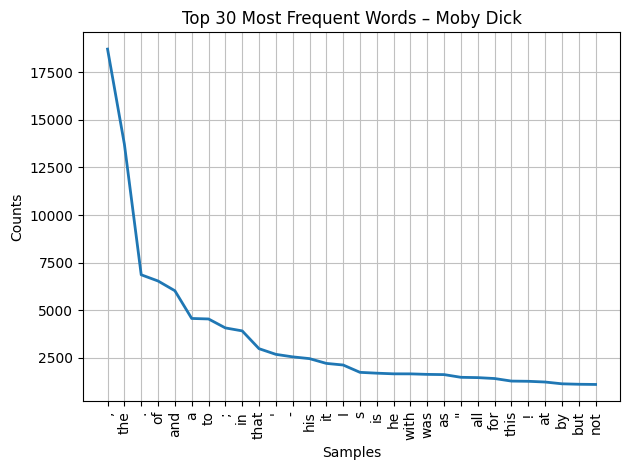

In [18]:
import matplotlib.pyplot as plt

fdist.plot(30, title='Top 30 Most Frequent Words – Moby Dick')
plt.tight_layout()
plt.show()

In [19]:
# Hapaxes: words that appear exactly once
hapaxes = fdist.hapaxes()
print(f'Number of hapaxes: {len(hapaxes):,}')
print(f'Sample hapaxes: {hapaxes[:15]}')

Number of hapaxes: 9,002
Sample hapaxes: ['Herman', 'Melville', ']', 'ETYMOLOGY', 'Late', 'Consumptive', 'School', 'threadbare', 'lexicons', 'mockingly', 'flags', 'mortality', 'signification', 'HACKLUYT', 'Sw']


In [20]:
# Collocations: frequently co-occurring word pairs
print('Collocations in Moby Dick:')
text1.collocations()

Collocations in Moby Dick:
Sperm Whale; Moby Dick; White Whale; old man; Captain Ahab; sperm
whale; Right Whale; Captain Peleg; New Bedford; Cape Horn; cried Ahab;
years ago; lower jaw; never mind; Father Mapple; cried Stubb; chief
mate; white whale; ivory leg; one hand


## 6. A Taste of NLP Tasks

Let's preview several NLP tasks — each will be covered in depth in later lectures.

In [21]:
from nltk.tokenize import word_tokenize, sent_tokenize

sample = """Natural Language Processing is fascinating.
It combines linguistics, computer science, and AI.
Dr. Smith at MIT is a leading researcher in this field."""

# Sentence tokenization
sentences = sent_tokenize(sample)
print('Sentences:')
for i, s in enumerate(sentences, 1):
    print(f'  {i}. {s}')

# Word tokenization
words = word_tokenize(sample)
print(f'\nWord tokens ({len(words)} total):')
print(words)

Sentences:
  1. Natural Language Processing is fascinating.
  2. It combines linguistics, computer science, and AI.
  3. Dr. Smith at MIT is a leading researcher in this field.

Word tokens (28 total):
['Natural', 'Language', 'Processing', 'is', 'fascinating', '.', 'It', 'combines', 'linguistics', ',', 'computer', 'science', ',', 'and', 'AI', '.', 'Dr.', 'Smith', 'at', 'MIT', 'is', 'a', 'leading', 'researcher', 'in', 'this', 'field', '.']


In [22]:
# POS Tagging
import nltk
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')
tagged = pos_tag(word_tokenize('The quick brown fox jumps over the lazy dog'))
print('POS Tags:')
for word, tag in tagged:
    print(f'  {word:12s} → {tag}')
print('\nKey tags: NN=Noun, VBZ=Verb, JJ=Adjective, DT=Determiner, IN=Preposition')

POS Tags:
  The          → DT
  quick        → JJ
  brown        → NN
  fox          → NN
  jumps        → VBZ
  over         → IN
  the          → DT
  lazy         → JJ
  dog          → NN

Key tags: NN=Noun, VBZ=Verb, JJ=Adjective, DT=Determiner, IN=Preposition


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/lei/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [23]:
# Named Entity Recognition
from nltk import ne_chunk
nltk.download('maxent_ne_chunker_tab')

sentence = 'Barack Obama was born in Hawaii and served as President of the United States.'
ne_tree = ne_chunk(pos_tag(word_tokenize(sentence)))

print('Named Entities:')
for subtree in ne_tree:
    if hasattr(subtree, 'label'):
        entity = ' '.join([w for w, t in subtree.leaves()])
        print(f'  [{subtree.label()}] {entity}')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/lei/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


Named Entities:
  [PERSON] Barack
  [PERSON] Obama
  [GPE] Hawaii
  [GPE] United States


## 7. NLP in Industry

```
Industry Use Case            NLP Technology
────────────────────────────────────────────────────
Search Engines           →   Query understanding, ranking
Virtual Assistants       →   Speech, NLU, dialogue
Customer Service         →   Chatbots, intent classification
Social Media             →   Sentiment, toxicity detection
Healthcare               →   Clinical NLP, drug extraction
Finance                  →   Earnings analysis, risk detection
Legal                    →   Contract review, document analysis
E-commerce               →   Reviews, recommendation
Education                →   Essay grading, tutoring
```

According to *Practical Natural Language Processing* (Vajjala et al., 2020):
"NLP is no longer a research curiosity — it is at the heart of modern business intelligence, customer experience, and decision-making."

## Practice Exercises

**Exercise 1.1**: Write a function `lexical_diversity(text)` that computes the ratio of unique words to total words. Compare all six NLTK texts.

**Exercise 1.2**: Use `text4.dispersion_plot(['citizens', 'democracy', 'freedom', 'war'])` on the Inaugural Address corpus. What historical trends do you observe?

**Exercise 1.3**: Find all words in `text1` longer than 15 characters that appear more than once.

**Exercise 1.4**: Build a frequency distribution for `text6` (Monty Python). What are the most common content words (non-stopwords)?

In [24]:
# Exercise 1.1 starter
def lexical_diversity(text):
    """Ratio of unique words to total words."""
    # YOUR CODE HERE
    pass

from nltk.book import text1, text2, text3, text4, text5, text6
texts = {'Moby Dick': text1, 'Sense & Sensibility': text2,
         'Genesis': text3, 'Inaugural': text4, 'Chat': text5, 'Monty Python': text6}

for name, t in texts.items():
    score = lexical_diversity(t)
    print(f'{name}: {score}')

Moby Dick: None
Sense & Sensibility: None
Genesis: None
Inaugural: None
Chat: None
Monty Python: None


## Summary

| Concept | Key Takeaway |
|---------|-------------|
| NLP Definition | Computational understanding of human language |
| Why Hard | Ambiguity and context at every linguistic level |
| Core Tasks | Tokenization → POS → NER → Parsing → Classification → Generation |
| Key Libraries | NLTK (foundations), spaCy (production), HF Transformers (deep learning) |
| NLTK | Educational toolkit with corpora, lexical resources, algorithms |

**Next Lecture**: Python for Text Processing — string operations, tokenization, normalization.

---
*Book references: NLP with Python Ch.1 | Practical NLP Ch.1 | NLP with Transformers Ch.1*

---
**Author: Lei Wu | © 2026 Lei Wu. All rights reserved. Unauthorized use is prohibited.**